# 03 — Quantitative Signal Analysis

This module focuses on transforming raw market and on-chain data into quantitative signals used for systematic trading strategies. The signals generated here evaluate momentum, volatility, and mean-reversion characteristics to inform subsequent backtesting and strategy formulation.

**Key Signals Implemented:**
1. Returns & Volatility Profiling
2. Relative Strength Index (RSI)
3. Moving Average Convergence Divergence (MACD)
4. Bollinger Bands & Volatility Squeezes
5. Volume Anomaly Detection
6. Cross-Asset Correlation Analysis

Processed signals are exported to `/data/processed/` for integration into the backtesting framework.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/crypto_quant_project/utils')
import config

%pip install -q pandas numpy matplotlib seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.options.display.float_format = '{:.4f}'.format
print('Setup complete.')

Mounted at /content/drive
✅ Config loaded
✅ Setup complete


In [2]:
# Load historical price and market data

def load_ohlc(coin: str) -> pd.DataFrame:
    path = f'{config.RAW_DATA}/{coin}_ohlc_1y.csv'
    df = pd.read_csv(path, index_col='timestamp', parse_dates=True)
    return df

def load_market(coin: str) -> pd.DataFrame:
    path = f'{config.RAW_DATA}/{coin}_market_1y.csv'
    df = pd.read_csv(path, index_col='timestamp', parse_dates=True)
    return df

btc = load_ohlc('bitcoin')
eth = load_ohlc('ethereum')
sol = load_ohlc('solana')

btc_market = load_market('bitcoin')

print('BTC:', btc.shape, '| ETH:', eth.shape, '| SOL:', sol.shape)
btc.tail(3)

BTC: (92, 5) | ETH: (92, 5) | SOL: (92, 5)


,open,high,low,close,coin
timestamp,,,,,
2026-04-09,67306.0000,72698.0000,66634.0000,71117.0000,bitcoin
2026-04-13,71004.0000,73721.0000,70522.0000,70757.0000,bitcoin
2026-04-17,70651.0000,75829.0000,70627.0000,75149.0000,bitcoin


## 1. Returns and Volatility Profiling

In [3]:
# Calculate periodic returns for performance baseline
btc['return_1d']  = btc['close'].pct_change()
btc['return_7d']  = btc['close'].pct_change(7)
btc['return_30d'] = btc['close'].pct_change(30)

# Calculate annualized rolling volatility
btc['vol_14d']  = btc['return_1d'].rolling(14).std() * np.sqrt(365)
btc['vol_30d']  = btc['return_1d'].rolling(30).std() * np.sqrt(365)

print('BTC Stats (Trailing 30 days):')
recent = btc[['return_1d', 'return_7d', 'vol_14d']].tail(30)
print(f'  Avg daily return   : {recent["return_1d"].mean()*100:.2f}%')
print(f'  Maximum return     : {recent["return_1d"].max()*100:.2f}%')
print(f'  Minimum return     : {recent["return_1d"].min()*100:.2f}%')
print(f'  Annualized vol     : {recent["vol_14d"].mean()*100:.1f}%')

BTC Stats (last 30 days):
  Avg daily return   : -0.36%
  Best day           : 7.26%
  Worst day          : -10.11%
  Annualized vol     : 82.0%

For reference: S&P 500 annualized vol is ~15-20%. Crypto is much higher.


## 2. Relative Strength Index (RSI)

Days RSI > 70 (overbought): 10
Days RSI < 30 (oversold)  : 18
Current RSI               : 62.7


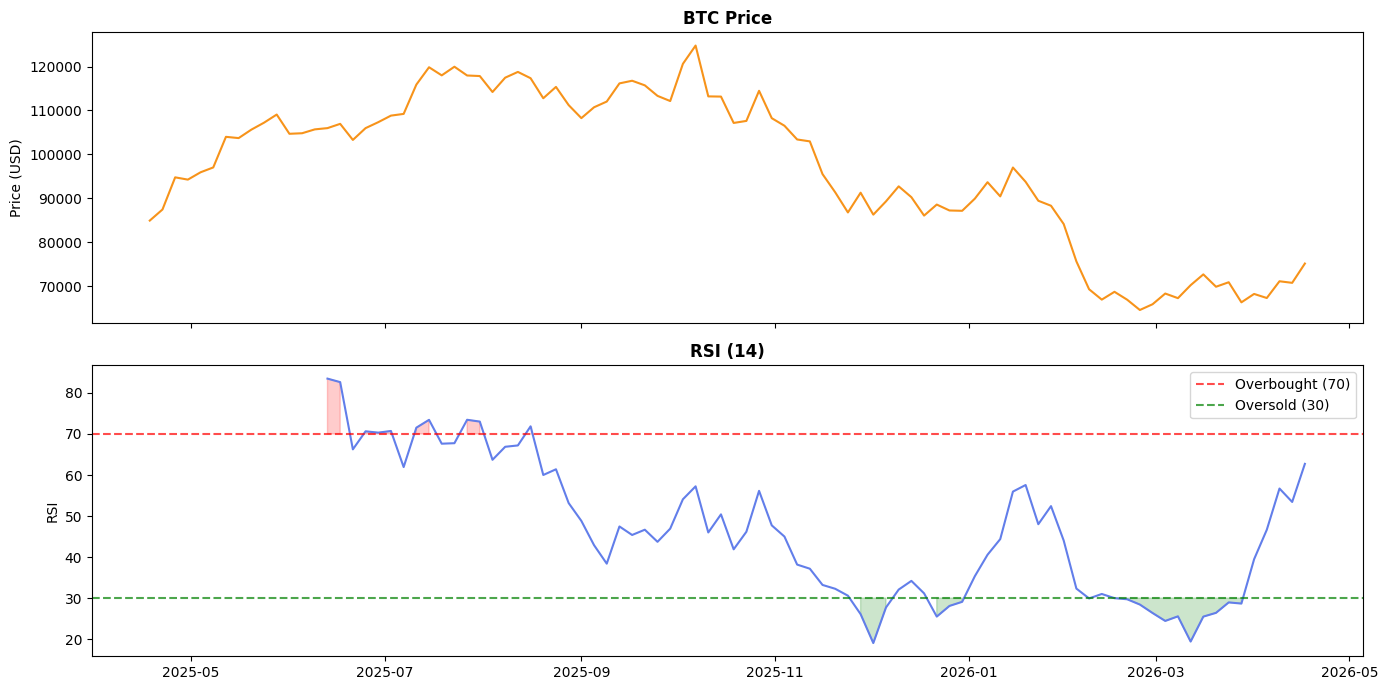

💾 Chart saved


In [4]:
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """Calculates the Relative Strength Index (RSI) for a given price series."""
    delta = series.diff()
    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = gains.rolling(period).mean()
    avg_loss = losses.rolling(period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

btc['rsi_14'] = compute_rsi(btc['close'], 14)

# Identify overbought/oversold technical thresholds
overbought = btc[btc['rsi_14'] > 70]
oversold = btc[btc['rsi_14'] < 30]

print(f'Periods RSI > 70 (Overbought): {len(overbought)}')
print(f'Periods RSI < 30 (Oversold)  : {len(oversold)}')
print(f'Current RSI                  : {btc["rsi_14"].iloc[-1]:.1f}')

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(btc.index, btc['close'], color='#f7931a', linewidth=1.5)
ax1.set_title('BTC Price', fontweight='bold')
ax1.set_ylabel('Price (USD)')

ax2.plot(btc.index, btc['rsi_14'], color='#627eea', linewidth=1.5)
ax2.axhline(70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
ax2.fill_between(btc.index, btc['rsi_14'], 70, where=btc['rsi_14']>70, alpha=0.2, color='red')
ax2.fill_between(btc.index, btc['rsi_14'], 30, where=btc['rsi_14']<30, alpha=0.2, color='green')
ax2.set_title('Relative Strength Index (14)', fontweight='bold')
ax2.set_ylabel('RSI')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{config.RESULTS_DIR}/btc_rsi.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Moving Average Convergence Divergence (MACD)

Bullish crossovers (buy signals) in past year : 5
Bearish crossovers (sell signals) in past year: 4


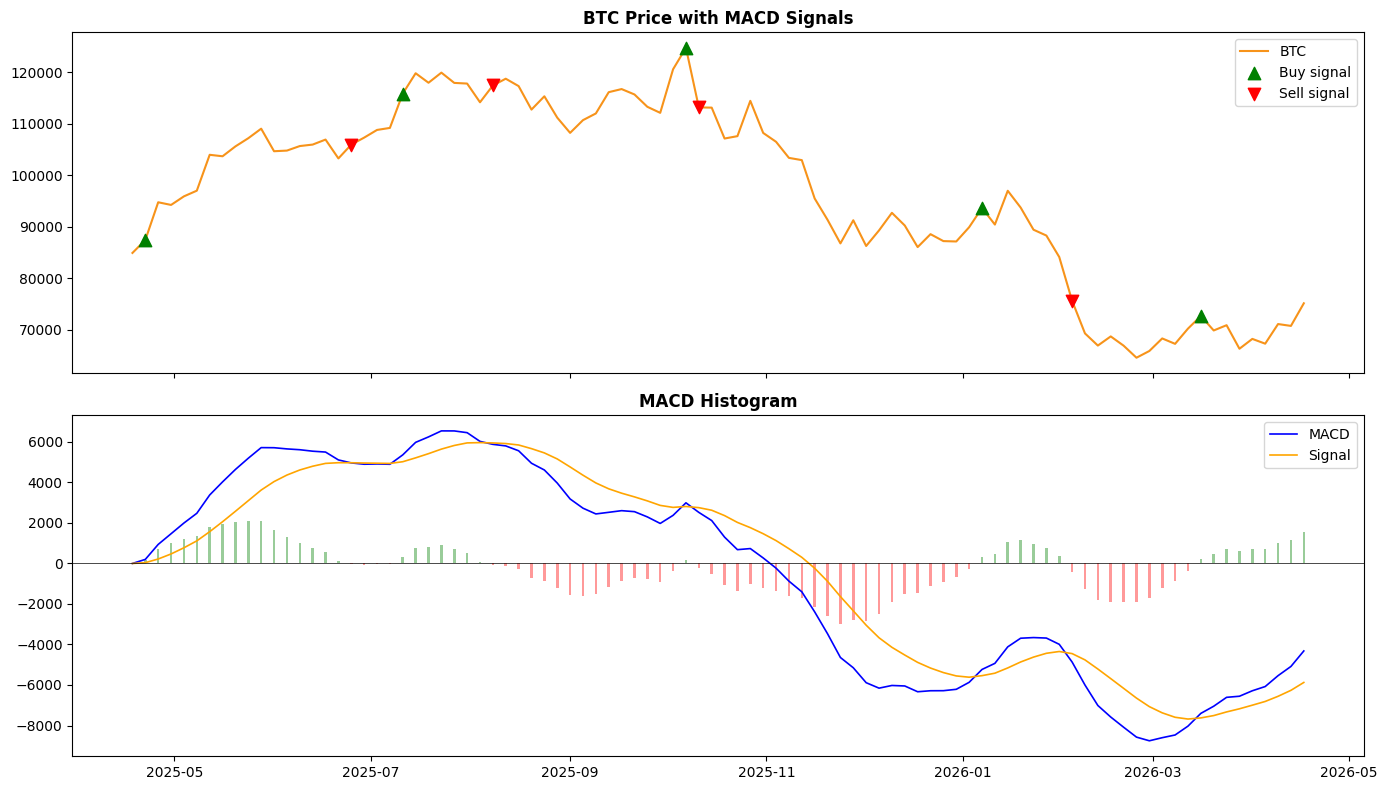

In [5]:
def compute_macd(series: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    """Computes the MACD line, signal line, and histogram."""
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

btc['macd'], btc['macd_signal'], btc['macd_hist'] = compute_macd(btc['close'])

# Identify crossover conditions
btc['macd_cross_up']   = (btc['macd'] > btc['macd_signal']) & (btc['macd'].shift(1) <= btc['macd_signal'].shift(1))
btc['macd_cross_down'] = (btc['macd'] < btc['macd_signal']) & (btc['macd'].shift(1) >= btc['macd_signal'].shift(1))

print(f'Bullish crossovers (1Y) : {btc["macd_cross_up"].sum()}')
print(f'Bearish crossovers (1Y) : {btc["macd_cross_down"].sum()}')

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(btc.index, btc['close'], color='#f7931a', linewidth=1.5, label='BTC')
buy_signals  = btc[btc['macd_cross_up']]
sell_signals = btc[btc['macd_cross_down']]
ax1.scatter(buy_signals.index,  buy_signals['close'],  marker='^', color='green', s=80, zorder=5, label='Bullish Cross')
ax1.scatter(sell_signals.index, sell_signals['close'], marker='v', color='red',   s=80, zorder=5, label='Bearish Cross')
ax1.set_title('BTC Price with MACD Indicators', fontweight='bold')
ax1.legend()

ax2.plot(btc.index, btc['macd'], color='blue', linewidth=1.2, label='MACD')
ax2.plot(btc.index, btc['macd_signal'], color='orange', linewidth=1.2, label='Signal')
ax2.bar(btc.index, btc['macd_hist'], color=np.where(btc['macd_hist'] >= 0, 'green', 'red'), alpha=0.4)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('MACD Histogram', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{config.RESULTS_DIR}/btc_macd.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Bollinger Bands and Volatility Squeeze Detection

Band squeezes detected: 15 days
Current %B (0=at lower, 1=at upper): 0.79


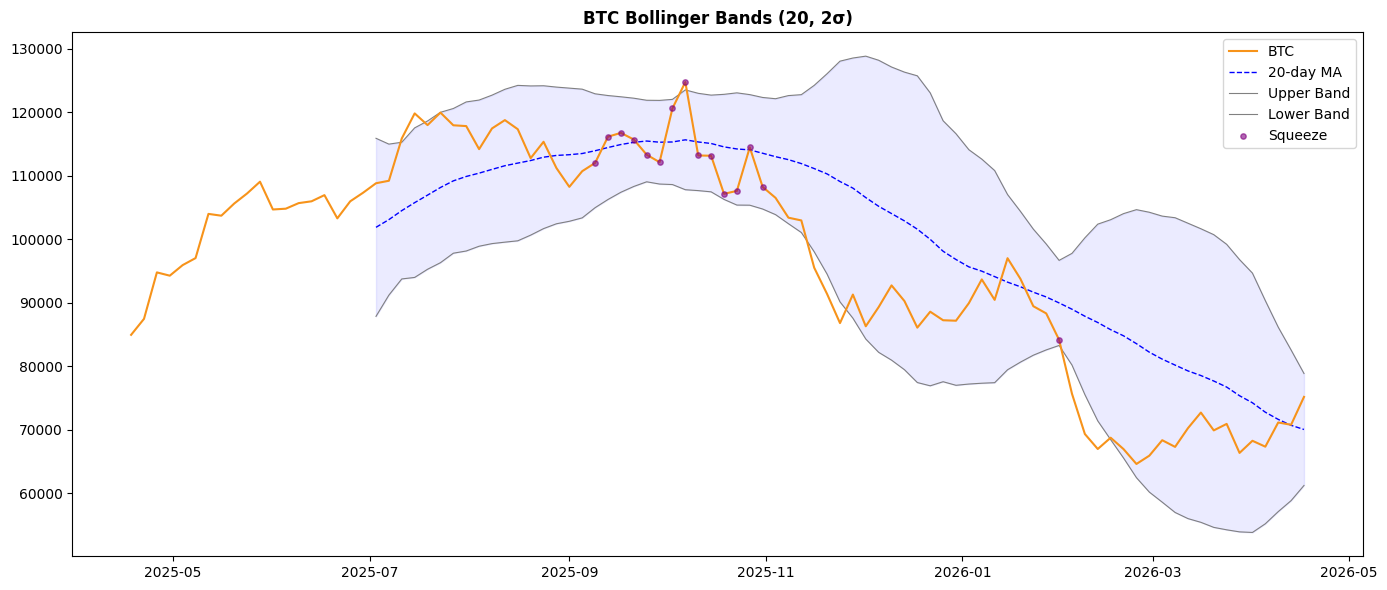

In [6]:
def compute_bollinger(series: pd.Series, window: int = 20, num_std: int = 2):
    """Calculates Bollinger Bands parameters including width and percent B."""
    mid = series.rolling(window).mean()
    std = series.rolling(window).std()
    upper = mid + num_std * std
    lower = mid - num_std * std
    width = (upper - lower) / mid
    pct_b = (series - lower) / (upper - lower)
    return mid, upper, lower, width, pct_b

btc['bb_mid'], btc['bb_upper'], btc['bb_lower'], btc['bb_width'], btc['bb_pct'] = compute_bollinger(btc['close'])

# Squeeze detection: Flag periods where band width falls below the 20th percentile
squeeze_threshold = btc['bb_width'].quantile(0.20)
btc['bb_squeeze'] = btc['bb_width'] < squeeze_threshold

print(f'Squeeze conditions detected: {btc["bb_squeeze"].sum()} periods')
print(f'Current %B: {btc["bb_pct"].iloc[-1]:.2f}')

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(btc.index, btc['close'], color='#f7931a', linewidth=1.5, label='BTC', zorder=3)
ax.plot(btc.index, btc['bb_mid'], color='blue', linewidth=1, linestyle='--', label='20-day SMA')
ax.plot(btc.index, btc['bb_upper'], color='grey', linewidth=0.8, label='Upper Band')
ax.plot(btc.index, btc['bb_lower'], color='grey', linewidth=0.8, label='Lower Band')
ax.fill_between(btc.index, btc['bb_upper'], btc['bb_lower'], alpha=0.08, color='blue')

# Highlight squeeze conditions
squeeze_periods = btc[btc['bb_squeeze']]
ax.scatter(squeeze_periods.index, squeeze_periods['close'], color='purple', s=15, alpha=0.6, label='Squeeze', zorder=4)

ax.set_title('Bollinger Bands Analysis (20, 2σ)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{config.RESULTS_DIR}/btc_bollinger.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Volume Anomaly Detection

In [7]:
# Identify abnormal trading volume indicating high institutional or market activity
btc_market['vol_ma30'] = btc_market['volume'].rolling(30).mean()
btc_market['vol_ratio'] = btc_market['volume'] / btc_market['vol_ma30']
btc_market['vol_anomaly'] = btc_market['vol_ratio'] > 2.0  # Threshold: 2x the 30-day average
btc_market['price_change'] = btc_market['price'].pct_change()

anomalies = btc_market[btc_market['vol_anomaly']].copy()

print(f'Anomalous volume periods detected: {len(anomalies)}')
print(f'Mean price change on anomalous days: {anomalies["price_change"].mean()*100:+.2f}%')
print(f'Mean price change on baseline days : {btc_market[~btc_market["vol_anomaly"]]["price_change"].mean()*100:+.2f}%')
print('\nTop 10 Volume Deviations:')

top_anomalies = anomalies.nlargest(10, 'vol_ratio')[['price', 'volume', 'vol_ratio', 'price_change']]
top_anomalies['vol_ratio'] = top_anomalies['vol_ratio'].map('{:.1f}x'.format)
top_anomalies['price_change'] = top_anomalies['price_change'].map('{:+.2%}'.format)
print(top_anomalies.to_string())

Volume anomalies detected: 7
Average price change on anomaly days: -1.33%
Average price change on normal days : +0.02%

10 Biggest Volume Spikes:
                 price            volume vol_ratio price_change
timestamp                                                      
2025-10-11 113201.7406 151002213089.8765      2.8x       -6.98%
2026-02-06  62853.6904 142403234254.4544      2.7x      -14.10%
2025-07-16 117678.1949  80299520980.2335      2.5x       -1.80%
2025-07-26 117540.8084  91617702596.1035      2.4x       -0.69%
2026-02-07  70523.9542 128662818793.5602      2.3x      +12.20%
2025-07-15 119833.6745  68915956378.8045      2.3x       +0.60%
2025-07-12 117571.0251  64185145923.8869      2.2x       +1.46%


## 6. Cross-Asset Correlation Matrix

Daily Return Correlation Matrix:
       BTC    ETH    SOL
BTC 1.0000 0.8390 0.8230
ETH 0.8390 1.0000 0.8680
SOL 0.8230 0.8680 1.0000


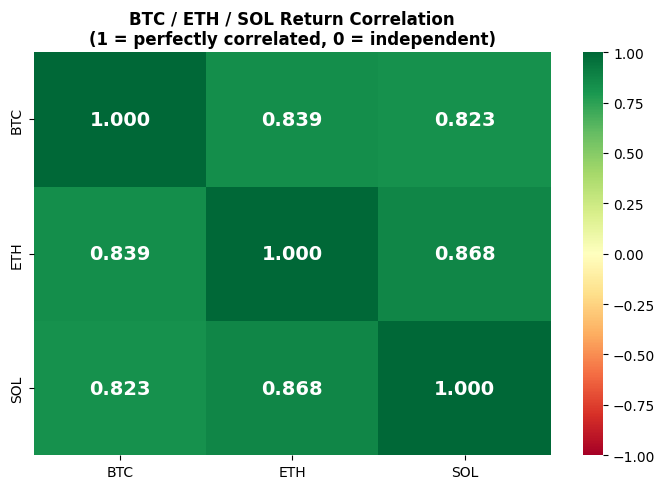


Insight: Crypto assets are highly correlated (0.7+). This means BTC is a
good leading indicator for ETH/SOL moves — useful for cross-asset strategies.


In [8]:
# Evaluate cross-asset correlations to measure dependency across the portfolio
eth_market = load_market('ethereum')
sol_market = load_market('solana')

# Synchronize temporal data series
prices = pd.DataFrame({
    'BTC': btc_market['price'],
    'ETH': eth_market['price'],
    'SOL': sol_market['price']
}).dropna()

# Compute correlation matrix based on daily returns
returns = prices.pct_change().dropna()
corr_matrix = returns.corr()

print('Daily Return Correlation Matrix:')
print(corr_matrix.round(3))

# Render correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Cross-Asset Return Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.RESULTS_DIR}/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Data Export for Backtesting Framework

In [9]:
# Compile engineered features into a singular dataframe for vector backtesting
signals = btc[[
    'open', 'high', 'low', 'close',
    'return_1d', 'return_7d',
    'vol_14d', 'vol_30d',
    'rsi_14',
    'macd', 'macd_signal', 'macd_hist',
    'macd_cross_up', 'macd_cross_down',
    'bb_mid', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct', 'bb_squeeze'
]].copy()

# Append resampled market volume
btc_market_daily = btc_market['volume'].resample('D').last()
signals = signals.join(btc_market_daily.rename('volume'), how='left')

# Purge initial rows containing undefined indicators due to lookback periods
signals = signals.dropna(subset=['rsi_14', 'macd', 'bb_mid'])

path = f'{config.PROCESSED_DATA}/btc_signals.csv'
signals.to_csv(path)
print(f'Persisted pipeline output: {path}')
print(f'Dimensionality: {signals.shape}\n')
print('Most recent feature vector:')
print(signals.iloc[-1][['close', 'rsi_14', 'macd', 'bb_pct', 'vol_14d']])

💾 Saved: /content/drive/MyDrive/crypto_quant_project/data/processed/btc_signals.csv
Shape: (73, 21)

Last row (most recent signals):
close     75149.0000
rsi_14       62.7179
macd      -4318.8832
bb_pct        0.7911
vol_14d       0.7348
Name: 2026-04-17 00:00:00, dtype: object


## Module Summary

Signal generation is complete. The engineered features successfully encapsulate momentum, volatility, volume patterns, and cross-asset correlations.

These validated signals are now persisted and ready for integration into the backtesting engine in the subsequent module.